# Task 4: Open-Set Recognition (OSR)
**Course:** EE-5102 / CS-6304: Advanced Topics in Machine Learning  
**Assignment:** Programming Assignment 1: Beyond IID and Closed-Set Assumptions  

In this task, we address open-set recognition on the CIFAR dataset:
- **Known Classes:** CIFAR-10.
- **Unknown Classes:** CIFAR-100 subsets (Near and Far semantic unknowns).
- **Methods Compared:**
  1. **Vanilla Classifier** (with post-hoc scoring: MSP, MLS, Energy, Mahalanobis)
  2. **GCSC** (Vanilla + Strong RandAugment)
  3. **PROSER** (Classifier & Data Placeholders via Manifold Mixup)


---
## Step 1: Environment Setup & Dataset Preparation

In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

from common.seed import set_seed, SEED
from task4.data.cifar10 import get_cifar10_datasets
from task4.data.cifar100_unknowns import get_cifar100_unknowns
from task4.train import train_osr_model
from task4.scores.msp import compute_msp_score
from task4.scores.mls import compute_mls_score
from task4.scores.energy import compute_energy_score
from task4.scores.mahalanobis import MahalanobisScorer
from task4.scores.proser_score import compute_proser_score
from task4.evaluation.metrics import compute_auroc, compute_fpr_at_95_tpr

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using hardware device: {DEVICE}")

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('figures/task4', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Datasets
cifar10_data = get_cifar10_datasets(use_randaug=False)
cifar100_data = get_cifar100_unknowns()

loader_val = DataLoader(cifar10_data['val'], batch_size=256, shuffle=False)
loader_test = DataLoader(cifar10_data['test'], batch_size=256, shuffle=False)
loader_near = DataLoader(cifar100_data['near'], batch_size=256, shuffle=False)
loader_far = DataLoader(cifar100_data['far'], batch_size=256, shuffle=False)

# For Mahalanobis fitting
loader_train_unaug = DataLoader(cifar10_data['train'], batch_size=256, shuffle=False)


Using hardware device: cuda


---
## Step 2: Training Vanilla, GCSC, and PROSER Models

In [2]:
def load_config(path):
    with open(path, 'r') as f:
        return yaml.safe_load(f)

configs = {
    'vanilla': load_config('task4/configs/vanilla.yaml'),
    'gcsc': load_config('task4/configs/gcsc.yaml'),
    'proser': load_config('task4/configs/proser.yaml')
}

models = {}
for name, cfg in configs.items():
    print(f"\n{'='*50}\nTraining {name.upper()}\n{'='*50}")
    # Train model or load if checkpoint exists
    ckpt_path = f"checkpoints/task4_{name}.pt"
    if os.path.exists(ckpt_path):
        from task4.models.resnet_cifar import CIFARResNet18
        model = CIFARResNet18(num_classes=10).to(DEVICE)
        if name == "proser":
            # Add dummy fc
            model.backbone.dummy_fc = nn.Linear(512, 5).to(DEVICE)
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        print(f"Loaded existing checkpoint for {name.upper()}")
    else:
        model = train_osr_model(name, cfg, DEVICE)
    model.eval()
    models[name] = model



Training VANILLA


Loaded existing checkpoint for VANILLA

Training GCSC
Loaded existing checkpoint for GCSC

Training PROSER


Loaded existing checkpoint for PROSER


---
## Step 3: Feature & Logit Extraction

In [3]:
def extract_outputs(model, loader):
    all_feats = []
    all_logits = []
    all_labels = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            feat, logits = model(x, return_feature=True)
            all_feats.append(feat.cpu())
            all_logits.append(logits.cpu())
            all_labels.append(y.cpu())
    return torch.cat(all_feats), torch.cat(all_logits), torch.cat(all_labels)

cache = {}
for name, model in models.items():
    print(f"Extracting features for {name.upper()}...")
    cache[name] = {
        'val': extract_outputs(model, loader_val),
        'test': extract_outputs(model, loader_test),
        'near': extract_outputs(model, loader_near),
        'far': extract_outputs(model, loader_far)
    }
    if name == 'vanilla':
        cache[name]['train'] = extract_outputs(model, loader_train_unaug)

# Fit Mahalanobis on Vanilla
mah_scorer = MahalanobisScorer(num_classes=10)
feat_tr, _, label_tr = cache['vanilla']['train']
mah_scorer.fit(feat_tr.to(DEVICE), label_tr.to(DEVICE))


Extracting features for VANILLA...


Extracting features for GCSC...


Extracting features for PROSER...


---
## Step 4: OSR Evaluation & Metrics

In [4]:
results = []

def eval_score(model_name, score_name, score_fn, use_mah=False, use_proser=False):
    c = cache[model_name]
    
    def get_score(split):
        feat, logits, _ = c[split]
        if use_mah:
            return score_fn(feat.to(DEVICE)).detach().cpu().numpy()
        elif use_proser:
            return score_fn(models[model_name], logits.to(DEVICE), feat.to(DEVICE)).detach().cpu().numpy()
        else:
            return score_fn(logits).detach().numpy()
            
    val_scores = get_score('val')
    test_scores = get_score('test')
    near_scores = get_score('near')
    far_scores = get_score('far')
    all_unknown_scores = np.concatenate([near_scores, far_scores])
    
    # AUROC
    auroc_near = compute_auroc(test_scores, near_scores) * 100
    auroc_far = compute_auroc(test_scores, far_scores) * 100
    auroc_all = compute_auroc(test_scores, all_unknown_scores) * 100
    
    # 95% TPR Thresholding
    tau, fpr_test, rej_near = compute_fpr_at_95_tpr(val_scores, test_scores, near_scores)
    _, _, rej_far = compute_fpr_at_95_tpr(val_scores, test_scores, far_scores)
    
    # Closed Set Acc
    logits_test = c['test'][1]
    labels_test = c['test'][2]
    preds = logits_test.argmax(dim=1)
    csa = (preds == labels_test).float().mean().item() * 100
    
    results.append({
        'Model': model_name.upper(),
        'Score': score_name,
        'CSA (%)': csa,
        'AUROC Near': auroc_near,
        'AUROC Far': auroc_far,
        'AUROC All': auroc_all,
        'FPR@95TPR (%)': fpr_test * 100,
        'Near Rej. (%)': rej_near * 100,
        'Far Rej. (%)': rej_far * 100
    })
    
    return val_scores, test_scores, near_scores, far_scores

# 1. Vanilla Post-Hoc
scores = {
    'MSP': lambda l: compute_msp_score(l),
    'MLS': lambda l: compute_mls_score(l),
    'Energy': lambda l: compute_energy_score(l),
    'Mahalanobis': mah_scorer.compute_score
}

vanilla_score_data = {}
for s_name, s_fn in scores.items():
    is_mah = (s_name == 'Mahalanobis')
    v, t, n, f = eval_score('vanilla', s_name, s_fn, use_mah=is_mah)
    vanilla_score_data[s_name] = {'val': v, 'test': t, 'near': n, 'far': f}

# 2. GCSC
eval_score('gcsc', 'MLS', lambda l: compute_mls_score(l))

# 3. PROSER
eval_score('proser', 'MLS', lambda l: compute_mls_score(l))
eval_score('proser', 'PROSER', compute_proser_score, use_proser=True)

df_results = pd.DataFrame(results)
display(df_results.round(2))


,Model,Score,CSA (%),AUROC Near,AUROC Far,AUROC All,FPR@95TPR (%),Near Rej. (%),Far Rej. (%)
0,VANILLA,MSP,94.80,80.84,89.32,85.08,5.74,29.38,47.62
1,VANILLA,MLS,94.80,79.36,88.47,83.91,5.40,32.88,54.25
2,VANILLA,Energy,94.80,79.35,88.49,83.92,5.41,33.38,54.00
3,VANILLA,Mahalanobis,94.80,77.74,91.33,84.53,5.57,30.00,53.87
4,GCSC,MLS,95.37,81.82,90.40,86.11,5.35,37.00,61.12
5,PROSER,MLS,94.71,79.92,87.42,83.67,5.06,30.75,49.38
6,PROSER,PROSER,94.71,74.71,89.91,82.31,5.18,28.62,56.38


---
## Step 5: Visualizations

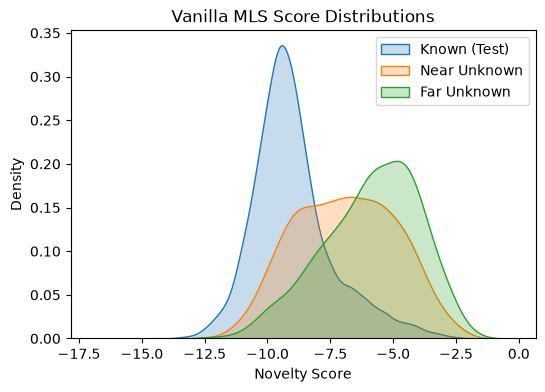

In [5]:
# Plot Score Distributions for Vanilla MLS
plt.figure(figsize=(6, 4))
mls_data = vanilla_score_data['MLS']
sns.kdeplot(mls_data['test'], label='Known (Test)', fill=True)
sns.kdeplot(mls_data['near'], label='Near Unknown', fill=True)
sns.kdeplot(mls_data['far'], label='Far Unknown', fill=True)
plt.title('Vanilla MLS Score Distributions')
plt.xlabel('Novelty Score')
plt.legend()
plt.savefig('figures/task4/score_distributions.png', bbox_inches='tight')
plt.show()

# Save results
df_results.to_json('results/task4_results.json', orient='records', indent=2)


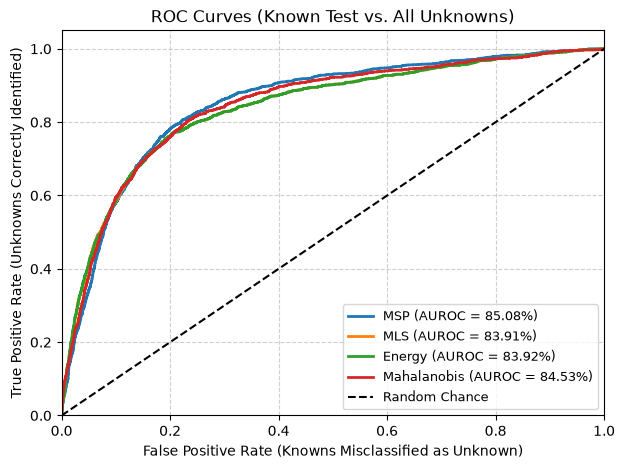

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 5))
for name, data in vanilla_score_data.items():
    s_test = data['test']
    s_unk = np.concatenate([data['near'], data['far']])
    y_true = np.concatenate([np.zeros_like(s_test), np.ones_like(s_unk)])
    y_scores = np.concatenate([s_test, s_unk])
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores) * 100
    plt.plot(fpr, tpr, label=f"{name} (AUROC = {auc:.2f}%)", lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Knowns Misclassified as Unknown)', fontsize=10)
plt.ylabel('True Positive Rate (Unknowns Correctly Identified)', fontsize=10)
plt.title('ROC Curves (Known Test vs. All Unknowns)', fontsize=12)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('figures/task4/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()


Validation threshold tau (95th percentile): -5.8506
Number of Near Unknowns incorrectly accepted: 537 / 800
Number of Far Unknowns incorrectly accepted: 366 / 800


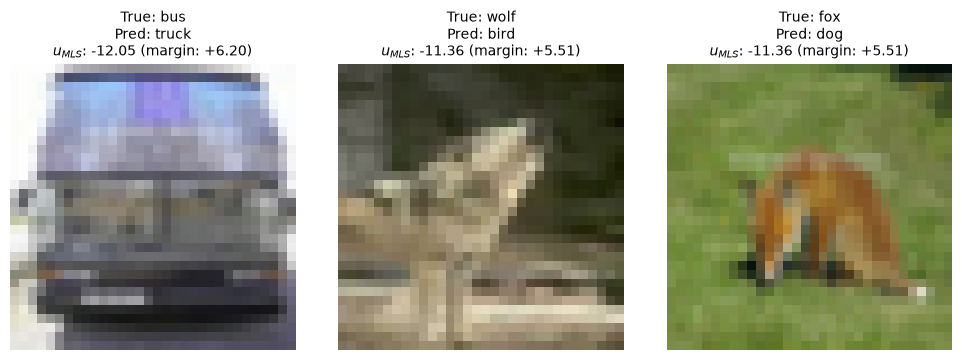

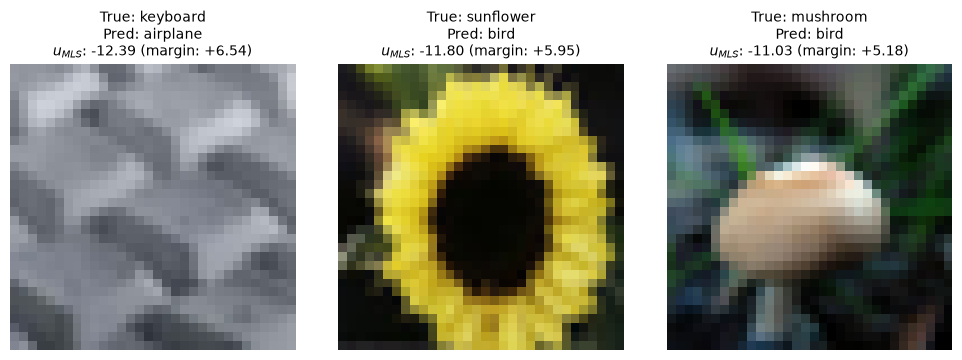

In [7]:
# Extract failure cases for qualitative analysis (Vanilla MLS)
tau = float(np.percentile(vanilla_score_data['MLS']['val'], 95))
near_mls = vanilla_score_data['MLS']['near']
far_mls = vanilla_score_data['MLS']['far']

near_acc_indices = np.where(near_mls <= tau)[0]
far_acc_indices = np.where(far_mls <= tau)[0]

print(f"Validation threshold tau (95th percentile): {tau:.4f}")
print(f"Number of Near Unknowns incorrectly accepted: {len(near_acc_indices)} / {len(near_mls)}")
print(f"Number of Far Unknowns incorrectly accepted: {len(far_acc_indices)} / {len(far_mls)}")

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
from torchvision import datasets
cifar100_raw = datasets.CIFAR100(root='data', train=False, download=True)
idx_to_c100 = {idx: name for name, idx in cifar100_raw.class_to_idx.items()}

mean = np.array([0.4914, 0.4822, 0.4465]).reshape(3, 1, 1)
std = np.array([0.2470, 0.2435, 0.2616]).reshape(3, 1, 1)

def unnorm(tensor):
    arr = tensor.cpu().numpy() * std + mean
    return np.transpose(np.clip(arr, 0, 1), (1, 2, 0))

_, logits_near, y_near = cache['vanilla']['near']
_, logits_far, y_far = cache['vanilla']['far']
preds_near = logits_near.argmax(dim=1).numpy()
preds_far = logits_far.argmax(dim=1).numpy()

# Select diverse near and far failures
sel_near = []
seen = set()
for idx in near_acc_indices[np.argsort(near_mls[near_acc_indices])]:
    c_name = idx_to_c100[y_near[idx].item()]
    if c_name not in seen:
        seen.add(c_name)
        sel_near.append(idx)
    if len(sel_near) == 3:
        break

sel_far = []
seen = set()
for idx in far_acc_indices[np.argsort(far_mls[far_acc_indices])]:
    c_name = idx_to_c100[y_far[idx].item()]
    if c_name not in seen:
        seen.add(c_name)
        sel_far.append(idx)
    if len(sel_far) == 3:
        break

# Plot Near Failures
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for i, idx in enumerate(sel_near):
    img_t, _ = cifar100_data['near'][idx]
    axes[i].imshow(unnorm(img_t))
    axes[i].axis('off')
    true_c = idx_to_c100[y_near[idx].item()]
    pred_c = cifar10_classes[preds_near[idx]]
    u = near_mls[idx]
    axes[i].set_title(f"True: {true_c}\nPred: {pred_c}\n$u_{{MLS}}$: {u:.2f} (margin: +{tau-u:.2f})", fontsize=10)
plt.tight_layout()
plt.savefig('figures/task4/near_unknown_failures.png', bbox_inches='tight', dpi=150)
plt.show()

# Plot Far Failures
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for i, idx in enumerate(sel_far):
    img_t, _ = cifar100_data['far'][idx]
    axes[i].imshow(unnorm(img_t))
    axes[i].axis('off')
    true_c = idx_to_c100[y_far[idx].item()]
    pred_c = cifar10_classes[preds_far[idx]]
    u = far_mls[idx]
    axes[i].set_title(f"True: {true_c}\nPred: {pred_c}\n$u_{{MLS}}$: {u:.2f} (margin: +{tau-u:.2f})", fontsize=10)
plt.tight_layout()
plt.savefig('figures/task4/far_unknown_failures.png', bbox_inches='tight', dpi=150)
plt.show()
